# **Adaboost**

https://youtu.be/LsK-xG1cLYA?si=XpskYpRQbehweHYr


Campus X -- https://youtu.be/RT0t9a3Xnfw?si=TGgB1cUEYXG26svd&t=494

Adaboost is a stagewise additive method.

### Core Concept
AdaBoost (Adaptive Boosting) works by sequentially fitting "weak learners" (typically decision stumps) on weighted versions of the training data. It gives more weight to the samples that were misclassified in the previous round, forcing the next learner to focus on the "hard" cases.

AdaBoost (Adaptive Boosting) is an ensemble machine learning algorithm that builds a strong predictive model by sequentially combining multiple weak learners—most commonly shallow decision trees (decision stumps). It works by assigning weights to each training sample and training models in a sequence, where each subsequent model focuses more on the samples that were misclassified by earlier models.

Initially, all data points are given equal importance. After each iteration, the algorithm increases the weights of incorrectly classified samples and decreases the weights of correctly classified ones. This forces the next weak learner to concentrate on harder cases. Each model is also assigned a weight based on its accuracy, and the final prediction is made by taking a weighted majority vote (for classification) or weighted sum (for regression) of all the learners.

### The Algorithm
1. **Initialize Weights**: Assign equal weights to all $N$ training examples: $w_i = 1/N$.
2. **Iterative Training**: For each iteration $m = 1, \dots, M$:
   - Fit a weak classifier $G_m(x)$ to the data using weights $w_i$.
   - Compute the error rate: $err_m = \frac{\sum_{i=1}^N w_i \mathbb{I}(y_i \neq G_m(x_i))}{\sum_{i=1}^N w_i}$.
   - Calculate the classifier's importance (influence): $\alpha_m = \ln\left(\frac{1 - err_m}{err_m}\right)$.
   - Update sample weights: $w_i \leftarrow w_i \cdot \exp[\alpha_m \cdot \mathbb{I}(y_i \neq G_m(x_i))]$.
3. **Final Prediction**: The final model is a weighted majority vote of all weak learners:
   $$G(x) = \text{sign} \left[ \sum_{m=1}^M \alpha_m G_m(x) \right]$$

### Key Characteristics
- **Adaptive**: It adapts to the errors of previous classifiers by re-weighting the dataset.
- **Weak Learners**: Usually uses Decision Stumps (trees with a single split) to prevent overfitting individual learners.
- **Sensitivity**: Highly sensitive to noisy data and outliers because it aggressively tries to correct misclassifications.
- **Ensemble Power**: Combines multiple high-bias, low-variance models into a single low-bias, low-variance model.






### Comparison: Bagging vs. Boosting

| Feature | Bagging (Bootstrap Aggregating) | Boosting |
| :--- | :--- | :--- |
| **Concept** | Parallel ensemble: Multiple models are trained independently. | Sequential ensemble: Models are trained in a series (one after another). |
| **Primary Goal** | Aimed at reducing **Variance** (prevents overfitting). | Aimed at reducing **Bias** and **Variance**. |
| **Data Selection** | Each model uses a random bootstrap sample (sampling with replacement). | Each model focuses on instances misclassified by the previous models. |
| **Weighting** | All models have equal weight in the final decision. | Models are weighted based on their individual performance. |
| **Dependency** | Models are independent; can be computed in parallel. | Models are dependent; subsequent models rely on previous errors. |
| **Final Prediction** | Simple majority vote or average. | Weighted majority vote or weighted average. |
| **Sensitivity** | **Robust to noise and outliers.** | **Sensitive to noise and outliers (may overfit noisy data).** |
| **Examples** | Random Forest, Bagging Meta-Estimator. | AdaBoost, Gradient Boosting (GBM), XGBoost, LightGBM. |
```


In boosting we take the models which has **high bias and low variance** (very shallow decision tee [a decision stump with max depth of 1]), but in case of bagging we take the models which has **low bias and high variance** (fully grown decision tree).

In boosting we have same models but we train them on different data, and each model is given a weightage based on its performance. The models are trained one after another based on the weightage of the previous model. The final prediction is the weighted sum of the predictions of all the models.

In bagging we have same models but we train them on different data, and all the models are given equal weightage, they get trained at the same time. The final prediction is the average of the predictions of all the models.

In boosting all the models have weightage, and the final prediction is the weighted sum of the predictions of all the models. So the model with high weightage is the one which is given more importance in the final prediction.

But in case of bagging all the models have equal weightage, and the final prediction is the average of the predictions of all the models.

# Pros and Cons of AdaBoost

AdaBoost is an incredibly powerful algorithm, but its sequential nature (learning from previous mistakes) gives it a very different set of strengths and weaknesses compared to parallel algorithms like Random Forest.

### ✅ Pros (Advantages)

| Pro | Explanation |
| :--- | :--- |
| **1. High Accuracy** | By forcing each new model to aggressively focus on the mistakes of the previous model, AdaBoost can take incredibly weak, simple models (like Stumps) and combine them into a highly complex, highly accurate final boundary. |
| **2. Not Prone to Overfitting** | Surprisingly, even though it focuses on errors, AdaBoost is remarkably resistant to overfitting. **Because it uses such simple, shallow base models (Stumps with only 1 split)**, it physically lacks the depth required to memorize the training data's noise. |
| **3. Very Few Hyperparameters** | AdaBoost is essentially ready "out-of-the-box." The only major hyperparameters you need to tune are `n_estimators` (how many Stumps to build) and `learning_rate` (how aggressively to update the weights). It works great immediately. |
| **4. Versatile (Can boost anything)** | While we almost exclusively use Decision Stumps, the AdaBoost algorithm is just a "wrapper." You can theoretically pass Logistic Regression, SVM, or any weak algorithm into AdaBoost to boost its performance! |

<br>

### ❌ Cons (Disadvantages)

| Con | Explanation |
| :--- | :--- |
| **1. Highly Sensitive to Outliers** | This is its biggest weakness. If you have a massive, noisy outlier in your data, Stump #1 will get it wrong. AdaBoost will mathematically inflate that outlier's weight. Stump #2 will get it wrong again, inflating it further. The algorithm will obsessively try to fix that single bad data point, warping the entire boundary and ruining the model. |
| **2. Slow to Train (Cannot use Parallel Processing)** | A Random Forest can train all 100 of its trees at the exact same time because they are independent `(n_jobs=-1)`. AdaBoost *cannot* do this. Because Stump #2 physically cannot be built until Stump #1 finishes calculating its errors and updating the weights, the algorithm must run sequentially (one at a time), making it slow on massive datasets. |
| **3. Harder to Interpret** | While a single Decision Stump is very easy to read, trying to unpack exactly how 100 sequentially weighted Stumps arrived at a final mathematical conclusion is very difficult to explain to non-technical stakeholders (it is a "Black Box"). |


---
---

# Can AdaBoost use *only* Decision Trees?

### 1. AdaBoost: Highly Flexible (Can use almost anything)
AdaBoost is just a theoretical **mathematical wrapper**. It doesn't actually care what model it is boosting. It simply says: *"Give me a weak model, and I will iteratively tell it which data points to focus on by changing their mathematical weights."*
*   **The Default:** In `scikit-learn`, `AdaBoostClassifier()` defaults to using a Decision Tree (specifically, a "Stump" with `max_depth=1`).
*   **The Reality:** You can theoretically pass almost any machine learning algorithm into its `estimator` parameter! You can easily build an AdaBoost ensemble using 100 Logistic Regression models, 100 Support Vector Machines (SVMs), or 100 Naive Bayes classifiers. 

```python
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
# You can Boost 100 Logistic Regression models!
ada_box = AdaBoostClassifier(estimator=LogisticRegression(), n_estimators=100)

---
---

### **Adaboost uses stumps for decision trees, then how it makes prediction in case of other models, for eg in case of logistic reg**

1. The Core Rule: You MUST keep the model "Weak"

    The secret to AdaBoost is that the base models must be terrible. If you give AdaBoost a Model 1 that is already 95% accurate, the algorithm completely breaks. There are no mistakes left for Model 2 and Model 3 to focus on, and the boosting process stops immediately.

Therefore, if you want to swap out a Stump and use Logistic Regression instead, you have to deliberately cripple the Logistic Regression model to make it "weak."

2. How to "Cripple" Logistic Regression

    A standard Logistic Regression model looks at all the features and carefully draws a highly accurate boundary line. This is too strong.

    To make it weak enough for AdaBoost, you must force it to underfit the data. You do this by turning up its Regularization Penalty (C):
        - You set $C$ to an incredibly low number (e.g., `C=0.01` or `0.001`).
        - This forces the Logistic Regression model to draw a terrible, flat, highly inaccurate boundary line.
        - The crippled Logistic Regression model is now acting exactly like a "Stump." It gets 49% of the points completely wrong!

3. How the Boosting Actually Happens
    Once you have your crippled Logistic Regression model, the AdaBoost process works exactly the same as it does with Stumps:

    - Model 1 (Crippled Logistic Regression): It draws its terrible boundary line. It gets 450 points right, and 550 points wrong.
    - The Penalty Weighting: AdaBoost finds the 550 points that Model 1 got wrong and mathematically inflates them, giving them massive weights.
    - Model 2 (Crippled Logistic Regression): AdaBoost hands the dataset to Model 2.
        - Here is the magic: Because scikit-learn's Logistic Regression algorithm supports sample_weights, Model 2 looks at those 550 massively inflated points and says, "Wow, the math is forcing me to care about these specific points right here."
        - Model 2 completely moves its terrible boundary line to correctly slice through those specific 550 heavy points.
    - The Sequence Continues: Model 3 focuses on what Model 2 missed, moving the boundary again.


At the end of the race, you don't have 100 Stumps. You have 100 slightly different Logistic Regression lines drawn all over your graph.

AdaBoost uses the exact same Voting System it always does. It looks at the mathematical accuracy of each of the 100 lines, assigns them a voting power (weight), and adds them all up.





---
---

# **Isnt it great if i make a strong base model, it will quickly give me the ans**

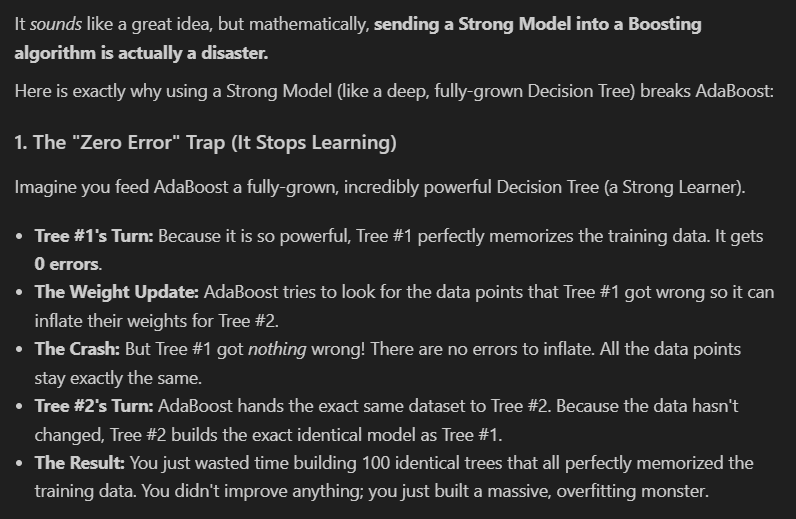

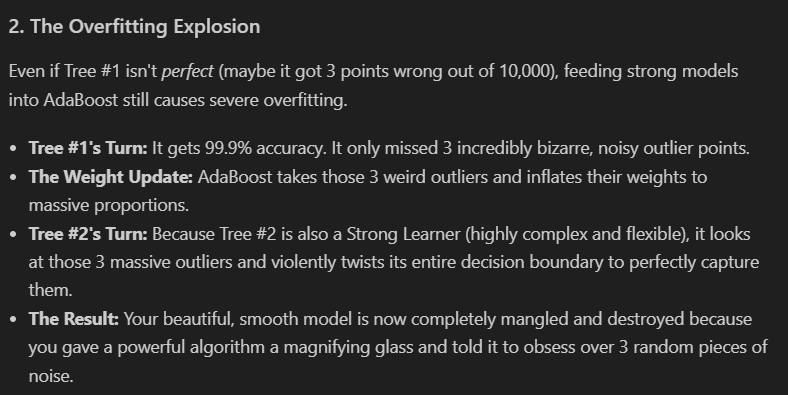

# **Then why shouldnt i use the strong model directly then using it via adaboost**

This is the final piece of the puzzle! If a single Strong Model (like a deep Decision Tree) can get you 95% accuracy right out of the box... why are we bothering with 100 weak, idiotic Stumps in AdaBoost?

The answer comes down to one of the most fundamental concepts in Machine Learning: The Bias-Variance Tradeoff.

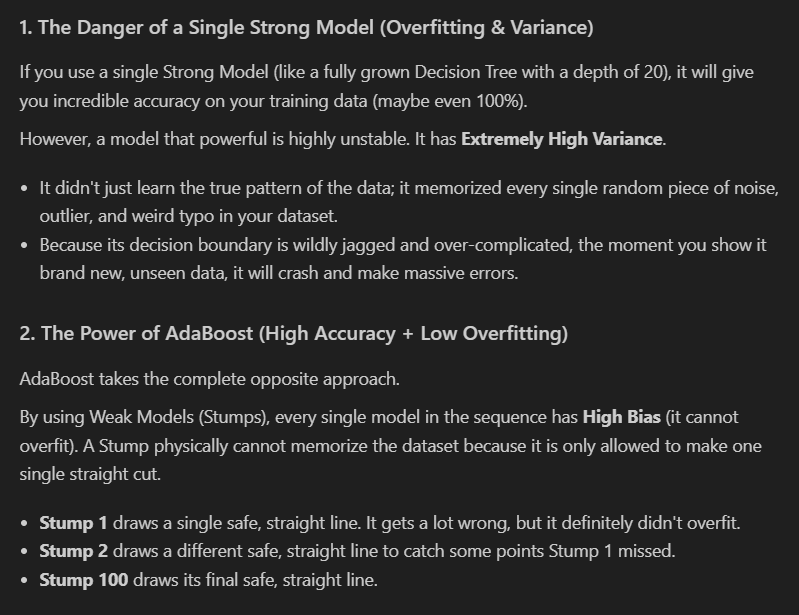

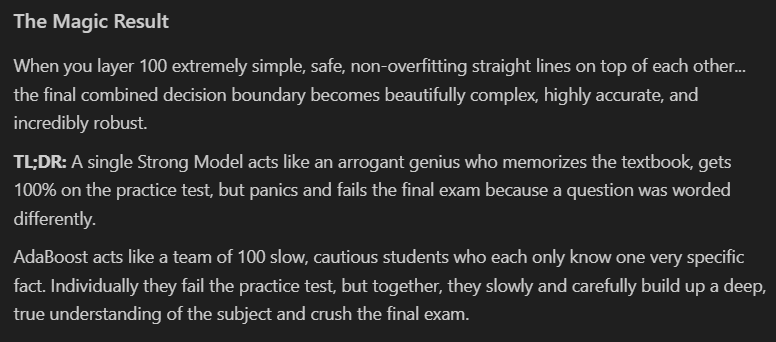